#  Temperature difference (δT) and  Salinity Difference (δS) Profiles for Greenland Fjords

**Author:** Emma Cameron  
**Institution:** University of St Andrews  

This notebook reproduces Figure 2 from the manuscript "Greenland fjord processes have a depth-dependent influence on predicted submarine melt rates" submitted to Geophysical research Letters. The script computes and visualises delta temperature (δT) and delta salinity (δS) profiles between near-glacier (NG) and fjord mouth CTD casts.

Profiles are:

- Binned onto a global depth grid (0–1000 m)
- Using 10 m bins
- Grouped by region (NW, CW, CE, SE)

Outputs:
- 4 × 2 subplot showing δT and δS profiles
- Profiles coloured by shallowest sill depth

Data sources:
- NetCDF CTD profiles (converted to conservative temperature and absolute salinity already)
- CSV file containing matched NG and mouth casts with metadata

In [1]:

# import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import netCDF4
import os
import pandas as pd

from matplotlib.transforms import ScaledTranslation
from matplotlib.ticker import MultipleLocator

## Plot formatting
Set global font sizes for axes tick labels.

In [2]:
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

## Global depth grid

Profiles are interpolated onto a common depth grid:

- Depth range: 0–1000 m
- Bin size: 10 m

This allows profiles from different casts to be compared directly.

In [3]:
global_bins = np.arange(0, 1000 + 10, 10) 
bin_centers = (global_bins[:-1] + global_bins[1:]) / 2
global_depth = len(bin_centers) 

# Helper Function
To help clean and pre-process the data

## Function: isolate_descent_phase()

CTD profiles often contain both the downcast and the upcast.

This function extracts only the downcast, defined as the section from the start of the profile to the **maximum depth**.



In [4]:
def isolate_descent_phase(depth, data):
    deepest_index = np.argmax(depth)
    return depth[:deepest_index + 1], data[:deepest_index + 1]

## Function: collect_profiles_from_csv()

This function:

1. Reads matched NG and fjord mouth CTD casts
2. Loads profiles from NetCDF files
3. Removes unrealistic temperatures
4. Bins temperature and salinity onto the global depth grid
5. Computes:

\[
δT = T_{NG} - T_{mouth}
\]

\[
δS = S_{NG} - S_{mouth}
\]

Profiles are grouped by region.

In [5]:
def collect_profiles_from_csv(filenames_df, directory):
    region_data = {}
    regions_order = ['CW', 'NW', 'CE', 'SE']

    # initialise data structure for each region
    for region in regions_order:
        region_data[region] = {
            'delta_T': [],
            'delta_S': [],
            'depth': bin_centers,  
            'sill_depths': [],
            'grounding_line_depth': [],
            'icepicks_id': []              
    }

    # loop over matched ng-mouth profile pairs from the CSV
    for idx, row in filenames_df.iterrows():
        icepicks_id = str(row['icepicks_id']).strip() # profile pairs are matched by icepicks_id

        # Remove profiles with bad salinity data
        if icepicks_id in ["1(2019)", "152(2019)"]:
            print(f"Skipping bad profile {icepicks_id}")
            continue
        
        # read in variables from the CSV
        region = row['region'].upper().strip()
        ng_file = row['ng_filename']
        mouth_file = row['mouth_filename']
        sill_depth = row['sill_depth']
        grounding_line_depth = row['grounding_line_depth']
    


        # Load NG and mouth profiles from .nc folder 
        try:
            with netCDF4.Dataset(os.path.join(directory, ng_file), 'r') as ds_ng: # open the netCDF file for the NG profile
                depth_ng = np.squeeze(ds_ng.variables['depth'][:])
                temp_ng = np.squeeze(ds_ng.variables['conservative_temperature'][:])
                salt_ng = np.squeeze(ds_ng.variables['absolute_salinity'][:])

                depth_ng, temp_ng = isolate_descent_phase(depth_ng, temp_ng)
                _, salt_ng = isolate_descent_phase(depth_ng, salt_ng)

            with netCDF4.Dataset(os.path.join(directory, mouth_file), 'r') as ds_mouth: # open the netCDF file for the mouth profile
                depth_mouth = np.squeeze(ds_mouth.variables['depth'][:])
                temp_mouth = np.squeeze(ds_mouth.variables['conservative_temperature'][:])
                salt_mouth = np.squeeze(ds_mouth.variables['absolute_salinity'][:])

                depth_mouth, temp_mouth = isolate_descent_phase(depth_mouth, temp_mouth)
                _, salt_mouth = isolate_descent_phase(depth_mouth, salt_mouth)

        except Exception as e:
            print(f"Error loading {ng_file} or {mouth_file}: {e}")
            continue

        # Filter out unrealistic temperatures
        valid_ng = temp_ng <= 50
        valid_mouth = temp_mouth <= 50
        
        # skip profiles that have no valid temperature data after filtering
        if not (np.any(valid_ng) and np.any(valid_mouth)):
            print(f"Skipping profile {icepicks_id} with no valid temperature data")
            continue
        
        # apply the filter 
        ng_depth_filt = depth_ng[valid_ng]
        ng_temp_filt  = temp_ng[valid_ng]
        ng_salt_filt  = salt_ng[valid_ng]

        mouth_depth_filt = depth_mouth[valid_mouth]
        mouth_temp_filt  = temp_mouth[valid_mouth]
        mouth_salt_filt  = salt_mouth[valid_mouth]

        # Binning
        # Create arrays to hold binned values, initialized with NaNs
        ng_T_global = np.full(global_depth, np.nan) 
        ng_S_global = np.full(global_depth, np.nan)
        mouth_T_global = np.full(global_depth, np.nan)
        mouth_S_global = np.full(global_depth, np.nan)

        ## Loop through each depth bin and calculate mean temperature and salinity for NG and mouth profiles
        
        # zip(global_bins[:-1], global_bins[1:]) pairs the lower and upper edges
        # of each 10 m bin (e.g. 0–10 m, 10–20 m, 20–30 m, ...)
        for i, (lo, hi) in enumerate(zip(global_bins[:-1], global_bins[1:])):

            # Create boolean masks identifying measurements that fall within
            # the current depth bin for each profile
            #
            # Example:
            # if lo = 100 and hi = 110, this selects all data points between
            # 100 m ≤ depth < 110 m
            ng_mask = (ng_depth_filt >= lo) & (ng_depth_filt < hi)
            mouth_mask = (mouth_depth_filt >= lo) & (mouth_depth_filt < hi)

            # If there are any NG data points inside this bin,
            # compute the mean temperature and salinity within the bin
            #
            # np.nanmean is used so that any missing values (NaNs)
            # do not affect the average.
            if np.any(ng_mask):
                ng_T_global[i] = np.nanmean(ng_temp_filt[ng_mask])
                ng_S_global[i] = np.nanmean(ng_salt_filt[ng_mask])

            # Repeat the same process for the fjord mouth profile
            # This produces the binned temperature and salinity
            # on the same global depth grid.
            if np.any(mouth_mask):
                mouth_T_global[i] = np.nanmean(mouth_temp_filt[mouth_mask])
                mouth_S_global[i] = np.nanmean(mouth_salt_filt[mouth_mask])


        # ------------------------------------------------------------------
        # Calculate delta profiles
        # ------------------------------------------------------------------
        # Delta values represent the difference between conditions near the
        # glacier (NG) and at the fjord mouth:
        #
        #   ΔT = T_NG − T_mouth
        #   ΔS = S_NG − S_mouth
        #
        # Positive values therefore indicate that water near the glacier is
        # warmer or more saline than at the fjord mouth, while negative values
        # indicate cooler or fresher conditions near the glacier.

        delta_T = ng_T_global - mouth_T_global
        delta_S = ng_S_global - mouth_S_global

        # Store results
        region_data[region]['delta_T'].append(delta_T)
        region_data[region]['delta_S'].append(delta_S)
        region_data[region]['sill_depths'].append(sill_depth)
        region_data[region]['grounding_line_depth'].append(grounding_line_depth)
        region_data[region]['icepicks_id'].append(icepicks_id)

    return region_data


## Function: plot_4x2_profiles()

This function creates a **4 × 2 subplot** figure:

Columns represent regions:

- NW
- CW
- CE
- SE

Rows represent variables:

- Top row: ΔT profiles
- Bottom row: ΔS profiles

Profiles are coloured according to shallowest sill depth.

In [6]:
def plot_4x2_profiles(region_data, colormap, norm, outputDir):
    regions_order = ['NW', 'CW', 'CE', 'SE']
    fig, axes = plt.subplots(
    2, 4,
    figsize=(16, 10),
    sharey=True,
    constrained_layout=True
)
    #set subfigure labels
    labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)']
    axes_flat = axes.flatten()

    for label, ax in zip(labels, axes_flat):
        ax.text(0.0, 1.0, label, transform=ax.transAxes + ScaledTranslation(-30/72, 10/72, fig.dpi_scale_trans), fontsize=25, va='bottom', fontweight='bold')

    # Loop through each region and plot the delta profiles, colored by sill depth
    for col_idx, region in enumerate(regions_order):
        data = region_data[region]
        sorted_indices = np.argsort(data['sill_depths']) # sort profiles by sill depth for consistent coloring
        ax_T, ax_S = axes[0, col_idx], axes[1, col_idx] 

        for idx in sorted_indices: # loop through profiles in order of sill depth
            sill = data['sill_depths'][idx]
            color = colormap(norm(sill)) if pd.notna(sill) else 'grey'

            ax_T.plot(data['delta_T'][idx], data['depth'], '-', color=color)
            ax_S.plot(data['delta_S'][idx], data['depth'], '-', color=color)



        ax_T.set_title(region, fontsize=25)
        ax_T.set_xlabel(r"$\delta$T ($^\circ$C)", fontsize=20)
        ax_T.set_xlim(-6, 2)

        # minor ticks every 1
        ax_T.xaxis.set_minor_locator(MultipleLocator(1))

        # show minor tick marks
        ax_T.tick_params(axis='x', which='minor', length=4)
        
        ax_T.set_ylim(800, 0)
        ax_T.axvline(0, color='black', linestyle='--', linewidth=2, zorder=10)
    
        if col_idx == 0:
            ax_T.set_ylabel('Depth (m)', fontsize=20)

        ax_S.set_xlabel(r"$\delta$S (g/kg)", fontsize=20)
        ax_S.set_xlim(-1.5, 1.5)
    
        # minor ticks every 1
        ax_S.xaxis.set_minor_locator(MultipleLocator(0.5))

        # show minor tick marks
        ax_T.tick_params(axis='x', which='minor', length=4)
        ax_S.set_ylim(800, 0)
        ax_S.axvline(0, color='black', linestyle='--', linewidth=2, zorder=10)
    
        if col_idx == 0:
            ax_S.set_ylabel('Depth', fontsize=20)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=axes, location='right')
    cbar.set_label('Sill Depth (m)', fontsize=20)
    cbar.ax.tick_params(labelsize=20)


    plt.savefig(os.path.join(outputDir, "delta_profiles_sillDepth72hrs_10mBins_globalGrid_poster.png"), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

## Function: plot_profiles()

This is the main workflow function that calls the previous functions to make the plot.

Steps:
1. Load matched profile metadata from CSV
2. Filter pairs where time difference > 72 hours
3. Compute ΔT and ΔS profiles
4. Plot results coloured by sill depth

In [7]:
def plot_profiles(directory, csv_file, outputDir):
    # Load CSV
    filenames_df = pd.read_csv(csv_file)

    # Filter out rows where time_difference_hours > 72
    filenames_df = filenames_df[filenames_df['time_difference_hours'] <= 72].reset_index(drop=True)

    # Ensure region strings are consistent
    filenames_df['region'] = filenames_df['region'].str.upper().str.strip()

    # Compute actual min/max sill depths for color normalization
    valid_sill = filenames_df['sill_depth'].dropna()
    if len(valid_sill) == 0:
        raise ValueError("No valid sill_depth values found in the CSV.")
    sill_min, sill_max = valid_sill.min(), valid_sill.max()

    colormap = plt.cm.viridis.reversed()
    norm = mcolors.Normalize(vmin=sill_min, vmax=sill_max)

    # Collect delta profiles with colors based on actual sill depths
    region_data = collect_profiles_from_csv(filenames_df, directory)

    # Plot 4x2 profiles with colorbar scaled to real sill depths
    plot_4x2_profiles(region_data, colormap, norm, outputDir)

## Define input and output paths

see README.md for expected folder structure

Skipping bad profile 1(2019)
Skipping bad profile 152(2019)


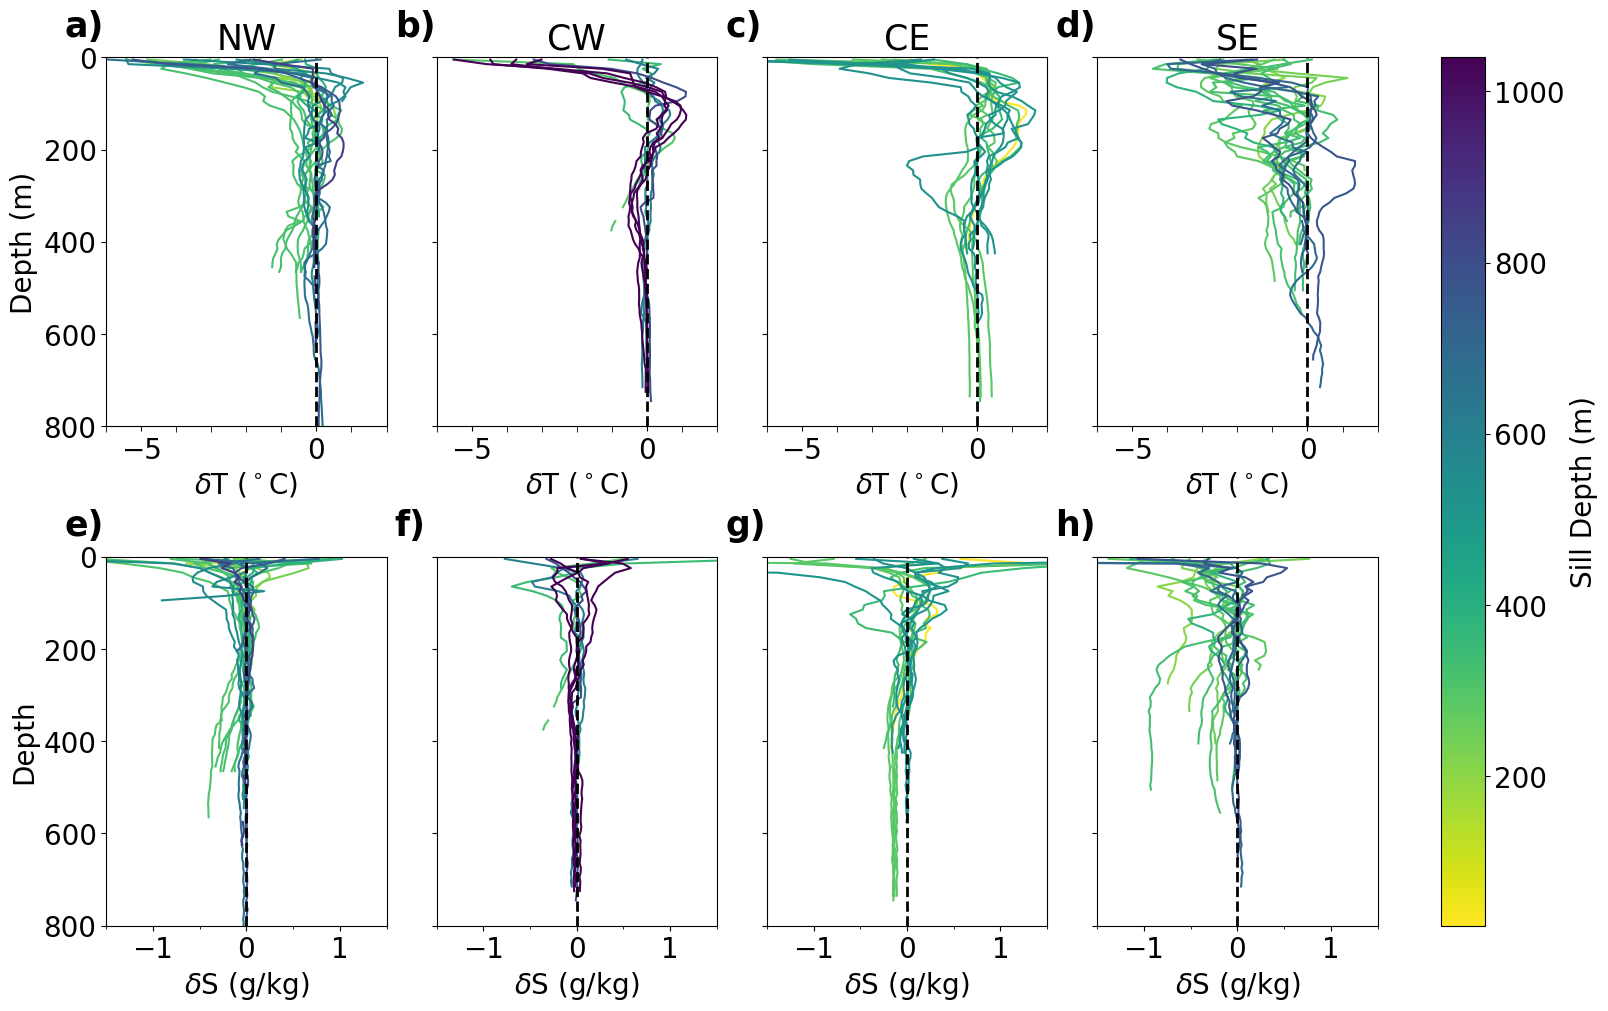

In [8]:
# Define file paths from config file 
from config_loader import load_paths

# Load all base paths
paths = load_paths()

csv_dir = paths["csv_dir"]
nc_dir = paths["nc_dir"]
results_root = paths["results_dir"]

# Script-specific output folder for plots
outputDir = results_root / "deltaProfiles_v3"
outputDir.mkdir(parents=True, exist_ok=True)

# Script-specific CSV file
csv_file = csv_dir / "matched_ng_mouth_with_metadata.csv"

# Now call the main function using config-based paths
plot_profiles(nc_dir, csv_file, outputDir)